In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
import sys
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 
import re
import string
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet = True)
nltk.download('punkt', quiet = True)
nltk.download('punkt_tab', quiet = True)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='darkgrid')

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
print("Loading dataset...")

df_raw = pd.read_csv('../data/raw/reviews.csv')

print(f"Dataset loaded successfully!")
print(f"Rows loaded : {df_raw.shape[0]:,}")
print(f"   Columns:        {df_raw.shape[1]}")
print(f"   Memory usage:   "
      f" {df_raw.memory_usage(deep = True).sum() / 1024**2:.2f} MB")

print("\nFIRST 3 ROWS:")
print("─" * 45)
display(df_raw.head(3))

print("\nCOLUMN INFO:")
print("─" * 45)
display(df_raw.info())

Loading dataset...
Dataset loaded successfully!
Rows loaded : 568,454
   Columns:        10
   Memory usage:    424.08 MB

FIRST 3 ROWS:
─────────────────────────────────────────────


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...



COLUMN INFO:
─────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


None

In [3]:
print("DATASET OVERVIEW")
print("=" * 50)

print("\n SCORE (STAR RATING) DISTRIBUTION:")
print("─" * 40)
score_counts = df_raw['Score'].value_counts().sort_index()

for star, count in score_counts.items():

    percentage = count / len(df_raw) * 100
    bar = '⭐' * star
    print(f'{bar} {star} stars:'
          f'{count:,} reviews ({percentage:.2f}%)')
    
print("\n MISSING VALUES:")
print("─" * 40)
missing = df_raw.isnull().sum()

for col, count in missing.items():
    if count > 0:
        pct = count / len(df_raw) * 100
        print(f"{col}: {count:,} missing values ({pct:.2f}%)")
    else:
        print(f"   {col}: No missing values")

print("\n REVIEW TEXT STATISTICS:")
print("─" * 40)
df_raw['text_length'] = df_raw['Text'].str.len()
df_raw['word_count'] = df_raw['Text'].str.split().str.len()

print(f"   Average review length: "
      f"{df_raw['text_length'].mean():.0f} characters")
print(f"   Average word count:    "
      f"{df_raw['word_count'].mean():.0f} words")
print(f"   Shortest review:       "
      f"{df_raw['text_length'].min()} characters")
print(f"   Longest review:        "
      f"{df_raw['text_length'].max():,} characters")

print("\n SAMPLE REVIEWS:")
print("─" * 40)

for score in [1, 3, 5]:

    sample = df_raw[df_raw['Score'] == score]['Text'].iloc[0]

    print(f"\n   ⭐ {score}-star review:")
    print(f"   '{sample[:150]}...'")

DATASET OVERVIEW

 SCORE (STAR RATING) DISTRIBUTION:
────────────────────────────────────────
⭐ 1 stars:52,268 reviews (9.19%)
⭐⭐ 2 stars:29,769 reviews (5.24%)
⭐⭐⭐ 3 stars:42,640 reviews (7.50%)
⭐⭐⭐⭐ 4 stars:80,655 reviews (14.19%)
⭐⭐⭐⭐⭐ 5 stars:363,122 reviews (63.88%)

 MISSING VALUES:
────────────────────────────────────────
   Id: No missing values
   ProductId: No missing values
   UserId: No missing values
ProfileName: 26 missing values (0.00%)
   HelpfulnessNumerator: No missing values
   HelpfulnessDenominator: No missing values
   Score: No missing values
   Time: No missing values
Summary: 27 missing values (0.00%)
   Text: No missing values

 REVIEW TEXT STATISTICS:
────────────────────────────────────────
   Average review length: 436 characters
   Average word count:    80 words
   Shortest review:       12 characters
   Longest review:        21,409 characters

 SAMPLE REVIEWS:
────────────────────────────────────────

   ⭐ 1-star review:
   'Product arrived labeled as J

In [4]:
# Cell 4 — Convert Unix Timestamp to Date

print("CONVERTING TIMESTAMP TO READABLE DATE")
print("─" * 45)

print(f"Sample BEFORE conversion:")
print(f"   {df_raw['Time'].iloc[0]}")

df_raw['Date'] = pd.to_datetime(df_raw['Time'], unit='s')

df_raw['Year'] = df_raw['Date'].dt.year

df_raw['Month'] = df_raw['Date'].dt.month

df_raw['YearMonth'] = df_raw['Date'].dt.to_period('M')

print(f"\nSample AFTER conversion:")
print(f"   Date:      {df_raw['Date'].iloc[0]}")
print(f"   Year:      {df_raw['Year'].iloc[0]}")
print(f"   Month:     {df_raw['Month'].iloc[0]}")
print(f"   YearMonth: {df_raw['YearMonth'].iloc[0]}")

print(f"\nDate range of reviews:")
print(f"   Earliest: {df_raw['Date'].min().strftime('%B %Y')}")

print(f"   Latest:   {df_raw['Date'].max().strftime('%B %Y')}")
print(f"\n Date conversion complete!")

CONVERTING TIMESTAMP TO READABLE DATE
─────────────────────────────────────────────
Sample BEFORE conversion:
   1303862400

Sample AFTER conversion:
   Date:      2011-04-27 00:00:00
   Year:      2011
   Month:     4
   YearMonth: 2011-04

Date range of reviews:
   Earliest: October 1999
   Latest:   October 2012

 Date conversion complete!


In [5]:
# Cell 5 — Calculating Helpfulness Ratio

print("CALCULATING HELPFULNESS RATIO")
print("─" * 45)

df_raw['helpfulness_ratio'] = (
    df_raw['HelpfulnessNumerator'] /
    df_raw['HelpfulnessDenominator'].replace(0, 1))

print(f"Average helpfulness: "
      f"{df_raw['helpfulness_ratio'].mean():.2f}")
print(f"Reviews with votes: "
      f"{(df_raw['HelpfulnessDenominator'] > 0).sum():,}")
print(f"Reviews with no votes: "
      f"{(df_raw['HelpfulnessDenominator'] == 0).sum():,}")
print("Helpfulness ratio calculated!")


CALCULATING HELPFULNESS RATIO
─────────────────────────────────────────────
Average helpfulness: 0.41
Reviews with votes: 298,402
Reviews with no votes: 270,052
Helpfulness ratio calculated!


In [6]:
# Cell 6 — Text Preprocessing

ENGLISH_STOPWORDS = set(stopwords.words('english'))

print(f"   Number of English stopwords: "
      f"{len(ENGLISH_STOPWORDS)}")

# FUNCTION 1: Minimal cleaning for VADER
def clean_for_vader(text):
    """
    Minimal cleaning for VADER sentiment analysis.

    KEEPS (because VADER uses these for scoring):
        Capitalization → "AMAZING" scores higher
        Exclamation marks → "great!!!" scores higher
        Emoticons → :) scores positive
        Question marks → signal uncertainty
        All punctuation → part of emotional signal

    REMOVES (no sentiment value):
        URLs → http://... adds nothing
        HTML tags → <br> adds nothing
        Extra whitespace → formatting only

    Parameters:
    -----------
    text : str
        One raw review string from the dataset

    Returns:
    --------
    str : Minimally cleaned text
    """
    if not isinstance(text, str):

        return ""
    
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = ' '.join(text.split())

    return text.strip()

# FUNCTION 2: Maximum cleaning for WordCloud/TF-IDF
def clean_for_wordcloud(text):
    """
    Maximum cleaning for WordCloud and TF-IDF.

    We want ONLY meaningful words.
    Word clouds visualize word FREQUENCY.
    TF-IDF finds most IMPORTANT words.

    Neither tool benefits from punctuation,
    numbers, stopwords, or capitalization.
    Including them creates noise in our visuals!

    REMOVES everything:
        URLs
        HTML tags
        Punctuation (!, ?, ., ,)
        Numbers (5, 100, 2024)
        Stopwords (the, is, and, a)
        Short words (2 characters or less)

    KEEPS only:
        Meaningful lowercase words

    Parameters:
    -----------
    text : str
        One raw review string

    Returns:
    --------
    str : Space-separated meaningful words
          Example: "amazing battery life excellent"
    """

    if not isinstance(text, str):

        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = ' '.join(text.split())

    tokens = word_tokenize(text)
    tokens = [
        word 
        for word in tokens
        if word not in ENGLISH_STOPWORDS and len(word) > 2
    ]
    return ' '.join(tokens)

test_review = (
    "This product is ABSOLUTELY AMAZING!!! "
    "Best purchase I've EVER made :) :) "
    "Visit http://amazon.com for details. "
    "5/5 stars. Would DEFINITELY recommend!!!"
)

print("\nORIGINAL REVIEW:")
print(f"'{test_review}'")

print("\n" + "─" * 50)
print("AFTER clean_for_vader():")
print(f"'{clean_for_vader(test_review)}'")
print("Notice: CAPS kept  !!! kept  :) kept ")

print("\n" + "─" * 50)
print("AFTER clean_for_wordcloud():")
print(clean_for_wordcloud(test_review))
print("Notice: only meaningful words remain ")

   Number of English stopwords: 198

ORIGINAL REVIEW:
'This product is ABSOLUTELY AMAZING!!! Best purchase I've EVER made :) :) Visit http://amazon.com for details. 5/5 stars. Would DEFINITELY recommend!!!'

──────────────────────────────────────────────────
AFTER clean_for_vader():
'This product is ABSOLUTELY AMAZING!!! Best purchase I've EVER made :) :) Visit for details. 5/5 stars. Would DEFINITELY recommend!!!'
Notice: CAPS kept  !!! kept  :) kept 

──────────────────────────────────────────────────
AFTER clean_for_wordcloud():
product absolutely amazing best purchase ive ever made visit details stars would definitely recommend
Notice: only meaningful words remain 


In [7]:
# Cell 7 — Apply Cleaning to All dataset Reviews

# Apply VADER cleaning
import time

print("Applying cleaning to all reviews...")
print("─" * 45)

start_time = time.time()

df_raw['text_for_vader'] = df_raw['Text'].apply(
    clean_for_vader
)

time_taken = time.time() - start_time

print(f"VADER cleaning completed! "
      f"({time_taken:.1f} seconds)")

# Apply WordCloud cleaning
start_time = time.time()

df_raw['text_for_wordcloud'] = df_raw['Text'].apply(
    clean_for_wordcloud
)

time_taken = time.time() - start_time

print(f"WordCloud cleaning completed! "
      f"({time_taken:.1f} seconds)")

print("\nVERIFICATION — Same review, both versions:")
print("─" * 50)

# Verify results on one example review
example_idx = 5

print("ORIGINAL:")
original = df_raw['Text'].iloc[example_idx]
print(f"'{original[:200]}...'")

print("\nFOR VADER:")
vader_version = df_raw['text_for_vader'].iloc[example_idx]
print(f"'{vader_version[:200]}...'")

print("\nFOR WORDCLOUD:")
wc_version = df_raw['text_for_wordcloud'].iloc[example_idx]
print(f"'{wc_version[:200]}...'")

print(f"\nDataset shape now: {df_raw.shape}")

Applying cleaning to all reviews...
─────────────────────────────────────────────
VADER cleaning completed! (9.0 seconds)
WordCloud cleaning completed! (199.9 seconds)

VERIFICATION — Same review, both versions:
──────────────────────────────────────────────────
ORIGINAL:
'I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable with many flavors: watermelon, root beer, melon, peppermint, grape, etc. My only complaint is there was a ...'

FOR VADER:
'I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable with many flavors: watermelon, root beer, melon, peppermint, grape, etc. My only complaint is there was a ...'

FOR WORDCLOUD:
'got wild hair taffy ordered five pound bag taffy enjoyable many flavors watermelon root beer melon peppermint grape etc complaint bit much redblack licoriceflavored pieces particular favorites kids hu...'

Dataset shape now: (568454, 19)


In [8]:
# Cell 8 — VADER Sentiment Analysis

print("TESTING VADER")
print("=" * 50)

analyzer = SentimentIntensityAnalyzer()

test_reviews = [
    "This product is absolutely AMAZING!!!",
    "Terrible quality. Complete waste of money!",
    "It is okay. Nothing special.",
    "I LOVE this! Works perfectly!!!",
    "not bad, not great either"
]

print("\nSAMPLE TESTS:")
print("─" * 50)

for review in test_reviews:
    scores  = analyzer.polarity_scores(review)
    compound = scores['compound']
    if compound >= 0.05:
        label = "POSITIVE"
    elif compound <= -0.05:
        label = "NEGATIVE"
    else:
        label = "NEUTRAL"

    print(f"Review: '{review}'")
    print(f"  Compound: {compound:+.3f} → {label}")
    print()

print("─" * 50)
print("Notice:")
print("'AMAZING!!!' → high positive (caps + !!!)")
print("'LOVE' + '!!!' → even higher")
print("This is why we preserved caps and !!! for VADER!")    

TESTING VADER

SAMPLE TESTS:
──────────────────────────────────────────────────
Review: 'This product is absolutely AMAZING!!!'
  Compound: +0.772 → POSITIVE

Review: 'Terrible quality. Complete waste of money!'
  Compound: -0.735 → NEGATIVE

Review: 'It is okay. Nothing special.'
  Compound: -0.092 → NEGATIVE

Review: 'I LOVE this! Works perfectly!!!'
  Compound: +0.906 → POSITIVE

Review: 'not bad, not great either'
  Compound: +0.675 → POSITIVE

──────────────────────────────────────────────────
Notice:
'AMAZING!!!' → high positive (caps + !!!)
'LOVE' + '!!!' → even higher
This is why we preserved caps and !!! for VADER!


In [9]:
# Cell 9 — Apply VADER to All dataset Reviews

print("Applying VADER to all reviews...")
print("─" * 45)

start_time = time.time()

all_vader_scores = df_raw['text_for_vader'].apply(
    analyzer.polarity_scores
)

elapsed = time.time() - start_time

print(f" VADER scoring complete! ({elapsed:.1f}s)")

df_raw['vader_compound'] = all_vader_scores.apply(
    lambda x: x['compound']
)

df_raw['vader_pos'] = all_vader_scores.apply(
    lambda x: x['pos']
)

df_raw['vader_neg'] = all_vader_scores.apply(
    lambda x: x['neg']
)

df_raw['vader_neu'] = all_vader_scores.apply(
    lambda x: x['neu']
)

print("Scores extracted into columns!")

def assign_vader_label(compound_score):
    """
    Converts VADER compound score to text label.

    Parameters:
    -----------
    compound_score : float
        VADER compound score between -1 and +1

    Returns:
    --------
    str : 'POSITIVE', 'NEGATIVE', or 'NEUTRAL'
    """
    if compound_score >= 0.05:
        return 'POSITIVE'
    elif compound_score <= -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

df_raw['sentiment'] = df_raw['vader_compound'].apply(
    assign_vader_label
)

print("Sentiment labels assigned!")

print("\nVADER SENTIMENT DISTRIBUTION:")
print("─" * 40)

label_counts = df_raw['sentiment'].value_counts()

total = len(df_raw)

for label, count in label_counts.items():
    percentage = (count / total) * 100
    bar = '█' * int(percentage / 2)
    print(f"  {label:<10} {count:>8,}  "
          f"({percentage:>5.1f}%)  {bar}")

Applying VADER to all reviews...
─────────────────────────────────────────────
 VADER scoring complete! (426.0s)
Scores extracted into columns!
Sentiment labels assigned!

VADER SENTIMENT DISTRIBUTION:
────────────────────────────────────────
  POSITIVE    501,284  ( 88.2%)  ████████████████████████████████████████████
  NEGATIVE     55,709  (  9.8%)  ████
  NEUTRAL      11,461  (  2.0%)  █


In [10]:
# Cell 10 — TextBlob Sentiment Analysis

print("TESTING TEXTBLOB")
print("=" * 50)

for review in test_reviews:
    blob = TextBlob(review)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    print(f"'{review[:45]}...'")
    print(f"  Polarity: {polarity:+.3f}  "
          f"Subjectivity: {subjectivity:.3f}")
    print()

print("─" * 50)

print("\nApplying TextBlob to all reviews...")

start_time = time.time()

def get_textblob_scores(text):
    """
    Gets TextBlob polarity and subjectivity scores.

    Parameters:
    -----------
    text : str
        One review string (cleaned)

    Returns:
    --------
    tuple : (polarity, subjectivity)
        polarity = float -1.0 to +1.0
        subjectivity = float 0.0 to 1.0
    """

    if not isinstance(text, str) or text.strip() == "":
        return (0.0, 0.0)
    blob = TextBlob(text)
    return (
        blob.sentiment.polarity,
        blob.sentiment.subjectivity
    )
 
tb_results = df_raw['text_for_vader'].apply(
    get_textblob_scores
)

df_raw['tb_polarity'] = tb_results.apply(lambda x: x[0])

df_raw['tb_subjectivity'] = tb_results.apply(lambda x: x[1])

def assign_textblob_label(polarity):
    """Converts TextBlob polarity to label."""
    if polarity > 0.05:
        return 'POSITIVE'
    elif polarity < -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

df_raw['tb_label'] = df_raw['tb_polarity'].apply(
    assign_textblob_label
)

elapsed = time.time() - start_time
print(f"TextBlob complete! ({elapsed:.1f}s)")

print("\nTEXTBLOB SENTIMENT DISTRIBUTION:")
print("─" * 40)
tb_counts = df_raw['tb_label'].value_counts()
for label, count in tb_counts.items():
    pct = (count / len(df_raw)) * 100
    print(f"  {label:<10} {count:>8,}  ({pct:>5.1f}%)")

print(f"\nSUBJECTIVITY INSIGHT:")
avg_subj = df_raw['tb_subjectivity'].mean()
print(f"  Average subjectivity: {avg_subj:.3f}")
print(f"  Meaning: reviews are mostly "
      f"{'subjective opinions' if avg_subj > 0.5 else 'objective facts'}")

TESTING TEXTBLOB
'This product is absolutely AMAZING!!!...'
  Polarity: +1.000  Subjectivity: 0.900

'Terrible quality. Complete waste of money!...'
  Polarity: -0.383  Subjectivity: 0.467

'It is okay. Nothing special....'
  Polarity: +0.429  Subjectivity: 0.536

'I LOVE this! Works perfectly!!!...'
  Polarity: +0.812  Subjectivity: 0.800

'not bad, not great either...'
  Polarity: -0.025  Subjectivity: 0.708

──────────────────────────────────────────────────

Applying TextBlob to all reviews...
TextBlob complete! (7349.0s)

TEXTBLOB SENTIMENT DISTRIBUTION:
────────────────────────────────────────
  POSITIVE    473,529  ( 83.3%)
  NEUTRAL      55,316  (  9.7%)
  NEGATIVE     39,609  (  7.0%)

SUBJECTIVITY INSIGHT:
  Average subjectivity: 0.550
  Meaning: reviews are mostly subjective opinions


In [11]:
# Cell 11 — Validate Results Against Star Ratings

print("VALIDATING SENTIMENT AGAINST STAR RATINGS")
print("=" * 55)

def star_to_label(score):
    """
    Converts 1-5 star rating to sentiment label.

    Parameters:
    -----------
    score : int
        Star rating (1, 2, 3, 4, or 5)

    Returns:
    --------
    str : 'POSITIVE', 'NEUTRAL', or 'NEGATIVE'
    """
    if score >= 4:
        return 'POSITIVE'
    elif score == 3:
        return 'NEUTRAL'
    else:
        return 'NEGATIVE'

df_raw['rating_label'] = df_raw['Score'].apply(
    star_to_label
)

vader_accuracy = (
    df_raw['sentiment'] == df_raw['rating_label']
).mean() * 100

tb_accuracy = (
    df_raw['tb_label'] == df_raw['rating_label']
).mean() * 100

print(f"\nACCURACY VS STAR RATINGS:")
print(f"─" * 40)
print(f"  VADER accuracy:    {vader_accuracy:.1f}%")
print(f"  TextBlob accuracy: {tb_accuracy:.1f}%")

print(f"\nDISTRIBUTION COMPARISON:")
print(f"{'':─<55}")
print(f"{'Label':<12} {'Star Rating':>12} "
      f"{'VADER':>10} {'TextBlob':>10}")
print(f"{'':─<55}")

for label in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
    rating_pct = (
        df_raw['rating_label'] == label
    ).mean() * 100

    vader_pct = (
        df_raw['sentiment'] == label
    ).mean() * 100

    tb_pct = (
        df_raw['tb_label'] == label
    ).mean() * 100

    print(f"{label:<12} {rating_pct:>11.1f}% "
          f"{vader_pct:>9.1f}% {tb_pct:>9.1f}%")

print(f"\n Higher accuracy = NLP matches human ratings!")
print(f"   VADER typically gets 70-80% on reviews")
print(f"   This validates our approach works!")

VALIDATING SENTIMENT AGAINST STAR RATINGS

ACCURACY VS STAR RATINGS:
────────────────────────────────────────
  VADER accuracy:    80.4%
  TextBlob accuracy: 75.9%

DISTRIBUTION COMPARISON:
───────────────────────────────────────────────────────
Label         Star Rating      VADER   TextBlob
───────────────────────────────────────────────────────
POSITIVE            78.1%      88.2%      83.3%
NEUTRAL              7.5%       2.0%       9.7%
NEGATIVE            14.4%       9.8%       7.0%

 Higher accuracy = NLP matches human ratings!
   VADER typically gets 70-80% on reviews
   This validates our approach works!


In [12]:
# Cell 12 — DataFrame Cleanup

print("CLEANING UP DATAFRAME")
print("=" * 45)
print(f"Columns BEFORE cleanup: {df_raw.shape[1]}")

columns_to_drop = [
    'vader_pos',
    'vader_neg',
    'vader_neu',
    'tb_polarity',
    'tb_label',
    'compound_bin',
    'Id',
    'UserId',
    'ProfileName',
    'HelpfulnessNumerator',
    'HelpfulnessDenominator',
    'Time',
]

df_raw = df_raw.drop(
    columns=columns_to_drop,
    errors='ignore'
)

print(f"Columns AFTER cleanup:  {df_raw.shape[1]}")

print(f"\nSentiment column check:")
print(f"  Exists: {'sentiment' in df_raw.columns}")
print(f"  Values: {df_raw['sentiment'].unique()}")
print(f"  Distribution:")
for label, count in df_raw['sentiment'].value_counts().items():
    pct = count / len(df_raw) * 100
    print(f"    {label:<10} {count:>8,} ({pct:.1f}%)")
    
print(f"\nFINAL COLUMNS:")
print("─" * 35)
for i, col in enumerate(df_raw.columns):
    print(f"  {i+1:2d}. {col}")


CLEANING UP DATAFRAME
Columns BEFORE cleanup: 28
Columns AFTER cleanup:  17

Sentiment column check:
  Exists: True
  Values: ['POSITIVE' 'NEGATIVE' 'NEUTRAL']
  Distribution:
    POSITIVE    501,284 (88.2%)
    NEGATIVE     55,709 (9.8%)
    NEUTRAL      11,461 (2.0%)

FINAL COLUMNS:
───────────────────────────────────
   1. ProductId
   2. Score
   3. Summary
   4. Text
   5. text_length
   6. word_count
   7. Date
   8. Year
   9. Month
  10. YearMonth
  11. helpfulness_ratio
  12. text_for_vader
  13. text_for_wordcloud
  14. vader_compound
  15. sentiment
  16. tb_subjectivity
  17. rating_label


In [13]:
# Cell 13 — Save Cleaned Processed Data

df_raw.to_csv(
    '../data/processed/reviews_with_sentiment.csv',
    index=False
)

print(" Saved to: '../data/processed/reviews_with_sentiment.csv' ")
print(f"   Rows: {df_raw.shape[0]:,}")
print(f"   Columns: {df_raw.shape[1]}")
print(f"   File size: "
      f"{os.path.getsize('../data/processed/reviews_with_sentiment.csv') / 1024**2:.1f} MB")

 Saved to: '../data/processed/reviews_with_sentiment.csv' 
   Rows: 568,454
   Columns: 17
   File size: 676.8 MB


In [14]:
# Cell 14 — Question 1: Sentiment Distribution

print("QUESTION 1: HOW IS SENTIMENT DISTRIBUTED?")
print("=" * 55)

sentiment_counts = df_raw['sentiment'].value_counts()
total_reviews = len(df_raw)

for label, count in sentiment_counts.items():
    pct = (count / total_reviews) * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<10} {count:>8,} ({pct:>5.1f}%) {bar}")

print("\nCOMPARISON: VADER vs STAR RATINGS:")
print("─" * 50)
print(f"{'Category':<12} {'VADER%':>8} {'Stars%':>8} {'Gap':>8}")
print("─" * 50)

for label in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
    vader_pct = (df_raw['sentiment'] == label).mean() * 100
    rating_pct = (df_raw['rating_label'] == label).mean() * 100

    gap = vader_pct - rating_pct

    print(f"  {label:<12} {vader_pct:>7.1f}% "
          f"{rating_pct:>7.1f}% {gap:>+7.1f}%")
    
print("\nSUBJECTIVITY BY SENTIMENT:")
print("─" * 45)
print("(0=objective fact, 1=personal opinion)")
print()

subj_by_sentiment = df_raw.groupby('sentiment')[
    'tb_subjectivity'
].mean()

for sentiment, avg_subj in subj_by_sentiment.items():
    interpretation = (
        "highly opinionated" if avg_subj > 0.6
        else "moderately opinionated" if avg_subj > 0.4
        else "relatively factual"
    )
    print(f"  {sentiment:<10} avg subjectivity: "
          f"{avg_subj:.3f} → {interpretation}")

print("\n→ KEY INSIGHT:")
most_common = sentiment_counts.index[0]
most_pct = (sentiment_counts.iloc[0] / total_reviews) * 100

print(f"   {most_pct:.1f}% of reviews are {most_common}")
print(f"   This dataset is heavily skewed!")
print(f"   Models trained on this data would be biased")
print(f"   toward predicting {most_common}")

QUESTION 1: HOW IS SENTIMENT DISTRIBUTED?
  POSITIVE    501,284 ( 88.2%) ████████████████████████████████████████████
  NEGATIVE     55,709 (  9.8%) ████
  NEUTRAL      11,461 (  2.0%) █

COMPARISON: VADER vs STAR RATINGS:
──────────────────────────────────────────────────
Category       VADER%   Stars%      Gap
──────────────────────────────────────────────────
  POSITIVE        88.2%    78.1%   +10.1%
  NEUTRAL          2.0%     7.5%    -5.5%
  NEGATIVE         9.8%    14.4%    -4.6%

SUBJECTIVITY BY SENTIMENT:
─────────────────────────────────────────────
(0=objective fact, 1=personal opinion)

  NEGATIVE   avg subjectivity: 0.522 → moderately opinionated
  NEUTRAL    avg subjectivity: 0.424 → moderately opinionated
  POSITIVE   avg subjectivity: 0.556 → moderately opinionated

→ KEY INSIGHT:
   88.2% of reviews are POSITIVE
   This dataset is heavily skewed!
   Models trained on this data would be biased
   toward predicting POSITIVE


QUESTION 2: DOES SENTIMENT MATCH STAR RATINGS?

CROSS TABULATION (row % of each star rating):
sentiment  POSITIVE  NEUTRAL  NEGATIVE
Score                                 
1             0.494    0.049     0.457
2             0.651    0.046     0.303
3             0.791    0.038     0.171
4             0.926    0.017     0.057
5             0.957    0.012     0.030


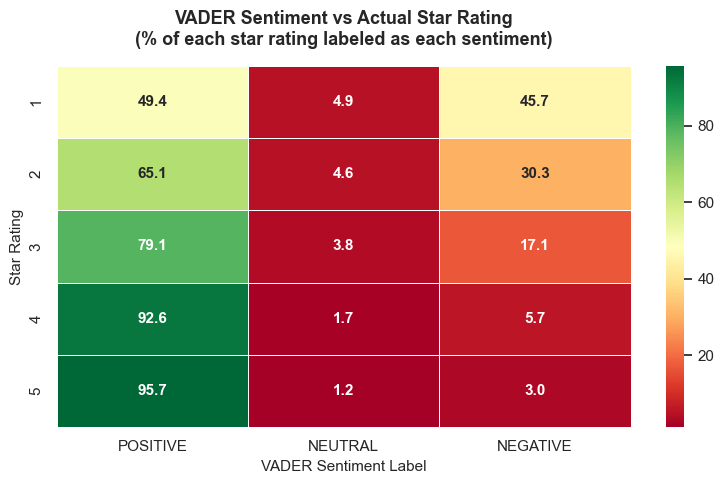

 Chart saved to outputs/!

INTERPRETATION:
─────────────────────────────────────────────
Green diagonal = VADER correct
Off-diagonal red = VADER mistakes

  1-star reviews: 49.4% labeled POSITIVE
  3-star reviews: 79.1% labeled POSITIVE
  5-star reviews: 95.7% labeled POSITIVE


In [15]:
# Cell 15 — Question 2: Does Sentiment Match Stars?

print("QUESTION 2: DOES SENTIMENT MATCH STAR RATINGS?")
print("=" * 55)

cross_tab = pd.crosstab(
    df_raw['Score'],
    df_raw['sentiment'],
    normalize='index'
)
cross_tab = cross_tab[['POSITIVE', 'NEUTRAL', 'NEGATIVE']]

print("\nCROSS TABULATION (row % of each star rating):")
print(cross_tab.round(3))

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    cross_tab * 100,        # convert proportions to percentages
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'}
)

ax.set_title(
    'VADER Sentiment vs Actual Star Rating\n'
    '(% of each star rating labeled as each sentiment)',
    fontsize=13,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('VADER Sentiment Label', fontsize=11)
ax.set_ylabel('Star Rating', fontsize=11)

plt.tight_layout()
plt.savefig(
    '../outputs/01_sentiment_vs_stars_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print(" Chart saved to outputs/!")
print("\nINTERPRETATION:")
print("─" * 45)
print("Green diagonal = VADER correct")
print("Off-diagonal red = VADER mistakes")
print()

for star in [1, 3, 5]:
    row = cross_tab.loc[star]
    dominant = row.idxmax()
    pct = row.max() * 100
    print(f"  {star}-star reviews: "
          f"{pct:.1f}% labeled {dominant}")

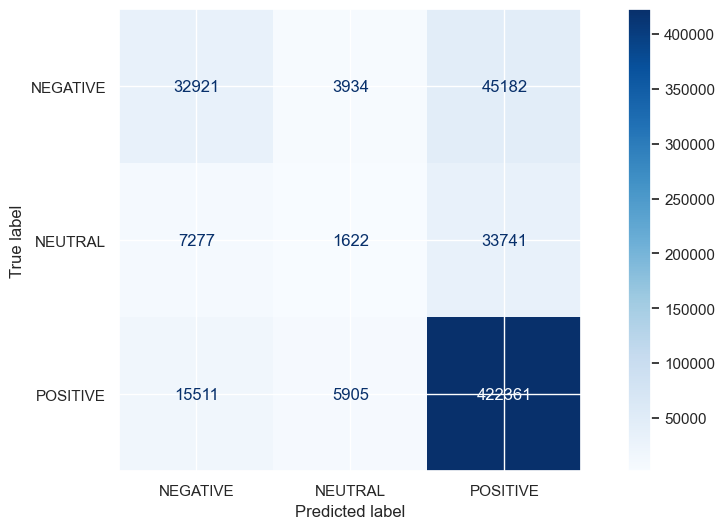

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    df_raw['rating_label'],
    df_raw['sentiment'],
    labels=['NEGATIVE','NEUTRAL','POSITIVE']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['NEGATIVE','NEUTRAL','POSITIVE']
)

disp.plot(cmap='Blues')
plt.show()

In [ ]:
mismatch = df_raw[
    df_raw['rating_label'] != df_raw['sentiment']
]

mismatch[
    ['Score','vader_compound','Text']
].head(20)

In [ ]:
final_score = (
    0.6 * df_raw['vader_compound']
    +
    0.4 * df_raw['tb_polarity']
)